(256, 256, 256)


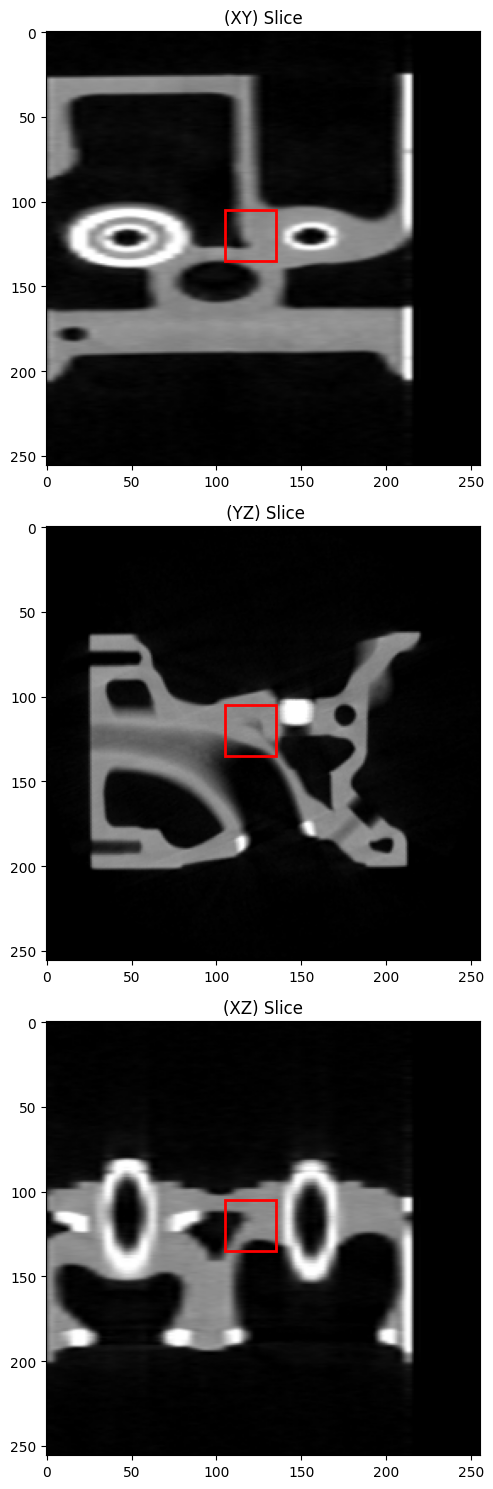

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load the volume
path = os.path.expanduser("image_of_engine/cone_ntrain_25_angle_360/2_engine_cone/vol_gt.npy")
data = np.load(path)
print(data.shape)

# --- Patch Configuration ---
patch_size = 30
center = [120, 120, 120]  # Center in (z, y, x)
start = [c - patch_size // 2 for c in center]
end = [s + patch_size for s in start]

# --- Plot Slices with Patch Highlight ---
fig, axs = plt.subplots(3, 1, figsize=(15, 15))  # <== changed to 3 rows x 1 column

# Axial (XY): slice at z = center[0]
axs[0].imshow(data[center[0], :, :], cmap='gray')
axs[0].set_title('(XY) Slice')
rect_xy = patches.Rectangle((start[2], start[1]), patch_size, patch_size,
                            linewidth=2, edgecolor='r', facecolor='none')
axs[0].add_patch(rect_xy)

# Sagittal (YZ): slice at x = center[2]
axs[1].imshow(data[:, :, center[2]], cmap='gray')
axs[1].set_title(' (YZ) Slice')
rect_yz = patches.Rectangle((start[1], start[0]), patch_size, patch_size,
                            linewidth=2, edgecolor='r', facecolor='none')
axs[1].add_patch(rect_yz)

# Coronal (XZ): slice at y = center[1]
axs[2].imshow(data[:, center[1], :], cmap='gray')
axs[2].set_title('(XZ) Slice')
rect_xz = patches.Rectangle((start[2], start[0]), patch_size, patch_size,
                            linewidth=2, edgecolor='r', facecolor='none')
axs[2].add_patch(rect_xz)


plt.tight_layout()
plt.show()


## Without Noise

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from types import SimpleNamespace
import sys
sys.path.append('..')
from unfold3d import Unfold3d
from field_of_junctions3d import FieldOfJunctions3D
import os
import math

path = os.path.expanduser("image_of_engine/cone_ntrain_25_angle_360/2_engine_cone/vol_gt.npy")
volume = np.load(path)
if volume.ndim == 3:
    volume = np.stack([volume] * 3, axis=-1)
print(volume.shape)

# Extract 3D patch
patch_size = 30
center = [150, 150, 150]

start = [c - patch_size // 2 for c in center]
end = [s + patch_size for s in start]

# Slice the patch
patch_np = volume[start[0]:end[0], start[1]:end[1], start[2]:end[2], :]

print("patch_np shape:", patch_np.shape)

opts = SimpleNamespace()
opts.R =10
opts.stride = 1
opts.eta = 0.01
opts.delta = 0.05
opts.lr_angles = 0.005
opts.lr_x0y0z0 = 0.05
opts.lambda_boundary_final = 0.1
opts.lambda_color_final = 0.001
opts.nvals = 5
opts.num_initialization_iters = 100
opts.num_refinement_iters = 1000
opts.greedy_step_every_iters = 50
opts.parallel_mode = True

# Define function for optimization
def foj_optimize_verbose():
    for i in range(foj.num_iters):
        if i == 0:
            print("Beginning initialization...")
        if i == opts.num_initialization_iters:
            print("Initialization done. Beginning refinement...")
        if i < opts.num_initialization_iters:
            if i % 5 == 0:
                print(f"Initialization iteration {i}/{opts.num_initialization_iters}")
        else:
            if i % 100 == 0:
                print(f"Refinement iteration {i}/{opts.num_refinement_iters}")
        foj.step(i)

# Run the Field of Junctions optimization
foj = FieldOfJunctions3D(patch_np, opts)
foj_optimize_verbose()

# Post-process
params = torch.cat([foj.angles, foj.x0y0z0], dim=1)
dists, _, patches = foj.get_dists_and_patches_3d(params)
local_boundaries = foj.dists2boundaries_3d(dists)
global_boundaries = foj.local2global_3d(local_boundaries)[0, 0].detach().cpu().numpy()
smoothed_img = foj.local2global_3d(patches)[0].permute(1, 2, 3, 0).detach().cpu().numpy()
print('smoothed image:', smoothed_img.shape)

(256, 256, 256, 3)
patch_np shape: (30, 30, 30, 3)
Beginning initialization...
Initialization iteration 0/100
Initialization iteration 5/100
Initialization iteration 10/100
Initialization iteration 15/100
Initialization iteration 20/100
Initialization iteration 25/100
Initialization iteration 30/100
Initialization iteration 35/100
Initialization iteration 40/100
Initialization iteration 45/100
Initialization iteration 50/100
Initialization iteration 55/100
Initialization iteration 60/100
Initialization iteration 65/100
Initialization iteration 70/100
Initialization iteration 75/100
Initialization iteration 80/100
Initialization iteration 85/100
Initialization iteration 90/100
Initialization iteration 95/100
Initialization done. Beginning refinement...
Refinement iteration 100/1000
Refinement iteration 200/1000
Refinement iteration 300/1000
Refinement iteration 400/1000
Refinement iteration 500/1000
Refinement iteration 600/1000
Refinement iteration 700/1000
Refinement iteration 800/100

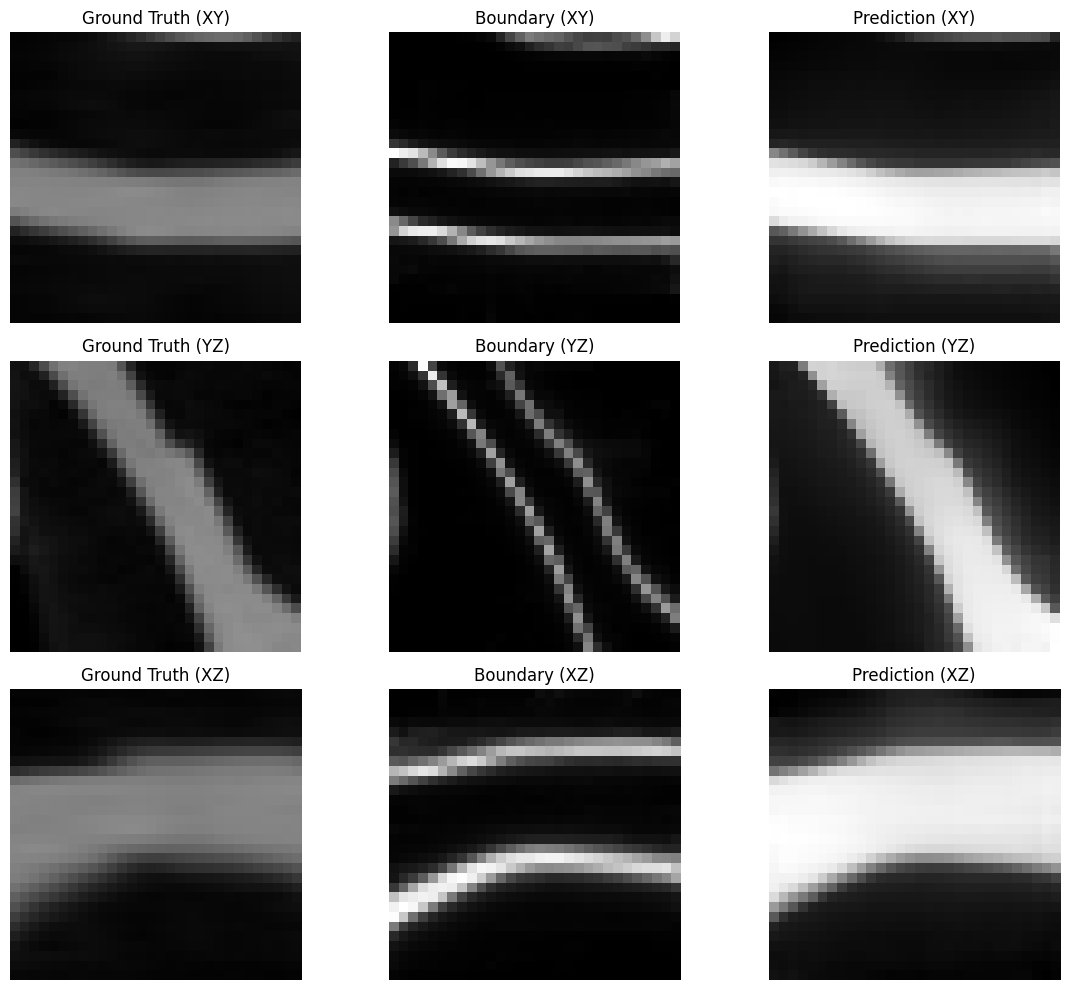

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize helper
def normalize_gray(x):
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# Convert [D, H, W, C] → [D, H, W] grayscale
gt_img = normalize_gray(patch_np.mean(axis=-1))           # Ground truth
pred_img = normalize_gray(smoothed_img.mean(axis=-1))     # Smoothed prediction
boundary_map = normalize_gray(global_boundaries)          # Detected boundaries

# Mid slice index
mid = gt_img.shape[0] // 2  # Assumes D = H = W

# Create figure
fig, axs = plt.subplots(3, 3, figsize=(12, 10))

# --- XY (Axial) ---
axs[0, 0].imshow(patch_np[mid], cmap='gray')
axs[0, 0].set_title('Ground Truth (XY)')
axs[0, 0].axis('off')

axs[0, 1].imshow(boundary_map[mid], cmap='gray')
axs[0, 1].set_title('Boundary (XY)')
axs[0, 1].axis('off')

axs[0, 2].imshow(pred_img[mid], cmap='gray')
axs[0, 2].set_title('Prediction (XY)')
axs[0, 2].axis('off')

# --- YZ (Sagittal) ---
axs[1, 0].imshow(patch_np[:, :, mid], cmap='gray')
axs[1, 0].set_title('Ground Truth (YZ)')
axs[1, 0].axis('off')

axs[1, 1].imshow(boundary_map[:, :, mid], cmap='gray')
axs[1, 1].set_title('Boundary (YZ)')
axs[1, 1].axis('off')

axs[1, 2].imshow(pred_img[:, :, mid], cmap='gray')
axs[1, 2].set_title('Prediction (YZ)')
axs[1, 2].axis('off')

# --- XZ (Coronal) ---
axs[2, 0].imshow(patch_np[:, mid, :], cmap='gray')
axs[2, 0].set_title('Ground Truth (XZ)')
axs[2, 0].axis('off')

axs[2, 1].imshow(boundary_map[:, mid, :], cmap='gray')
axs[2, 1].set_title('Boundary (XZ)')
axs[2, 1].axis('off')

axs[2, 2].imshow(pred_img[:, mid, :], cmap='gray')
axs[2, 2].set_title('Prediction (XZ)')
axs[2, 2].axis('off')

plt.tight_layout()
plt.show()


## With Noise

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from types import SimpleNamespace
import sys
sys.path.append('..')
from unfold3d import Unfold3d
from field_of_junctions3d import FieldOfJunctions3D
import os
import math

path = os.path.expanduser("image_of_engine/cone_ntrain_25_angle_360/2_engine_cone/vol_gt.npy")
volume = np.load(path)
if volume.ndim == 3:
    volume = np.stack([volume] * 3, axis=-1)
print(volume.shape)


# Extract 3D patch
patch_size = 30
center = [150, 150, 150]

start = [c - patch_size // 2 for c in center]
end = [s + patch_size for s in start]

# Slice the patch
patch_np = volume[start[0]:end[0], start[1]:end[1], start[2]:end[2], :]

print("patch_np shape:", patch_np.shape)

peak_photon_count =5
gray = patch_np.mean(axis=-1)  # shape: (D, H, W)
scaled = gray * peak_photon_count
noisy = np.random.poisson(scaled).astype(np.float32)
gray_poisson = np.clip(noisy / peak_photon_count, 0.0, 1.0)
patch_np_poisson = np.repeat(gray_poisson[..., np.newaxis], 3, axis=-1)

opts = SimpleNamespace()
opts.R =10
opts.stride = 1
opts.eta = 0.01
opts.delta = 0.05
opts.lr_angles = 0.005
opts.lr_x0y0z0 = 0.05
opts.lambda_boundary_final = 0.1
opts.lambda_color_final = 0.001
opts.nvals = 10
opts.num_initialization_iters = 100
opts.num_refinement_iters = 1000
opts.greedy_step_every_iters = 50
opts.parallel_mode = True

# Define function for optimization
def foj_optimize_verbose():
    for i in range(foj.num_iters):
        if i == 0:
            print("Beginning initialization...")
        if i == opts.num_initialization_iters:
            print("Initialization done. Beginning refinement...")
        if i < opts.num_initialization_iters:
            if i % 5 == 0:
                print(f"Initialization iteration {i}/{opts.num_initialization_iters}")
        else:
            if i % 100 == 0:
                print(f"Refinement iteration {i}/{opts.num_refinement_iters}")
        foj.step(i)

# Run the Field of Junctions optimization
foj = FieldOfJunctions3D(patch_np_poisson, opts)
foj_optimize_verbose()

# Post-process
params = torch.cat([foj.angles, foj.x0y0z0], dim=1)
dists, _, patches = foj.get_dists_and_patches_3d(params)
local_boundaries = foj.dists2boundaries_3d(dists)
global_boundaries = foj.local2global_3d(local_boundaries)[0, 0].detach().cpu().numpy()
smoothed_img = foj.local2global_3d(patches)[0].permute(1, 2, 3, 0).detach().cpu().numpy()
print('smoothed image:', smoothed_img.shape)

(256, 256, 256, 3)
patch_np shape: (30, 30, 30, 3)
Beginning initialization...
Initialization iteration 0/100
Initialization iteration 5/100
Initialization iteration 10/100
Initialization iteration 15/100
Initialization iteration 20/100
Initialization iteration 25/100
Initialization iteration 30/100
Initialization iteration 35/100
Initialization iteration 40/100
Initialization iteration 45/100
Initialization iteration 50/100
Initialization iteration 55/100
Initialization iteration 60/100
Initialization iteration 65/100
Initialization iteration 70/100
Initialization iteration 75/100
Initialization iteration 80/100
Initialization iteration 85/100
Initialization iteration 90/100
Initialization iteration 95/100
Initialization done. Beginning refinement...
Refinement iteration 100/1000
Refinement iteration 200/1000
Refinement iteration 300/1000
Refinement iteration 400/1000
Refinement iteration 500/1000
Refinement iteration 600/1000
Refinement iteration 700/1000
Refinement iteration 800/100

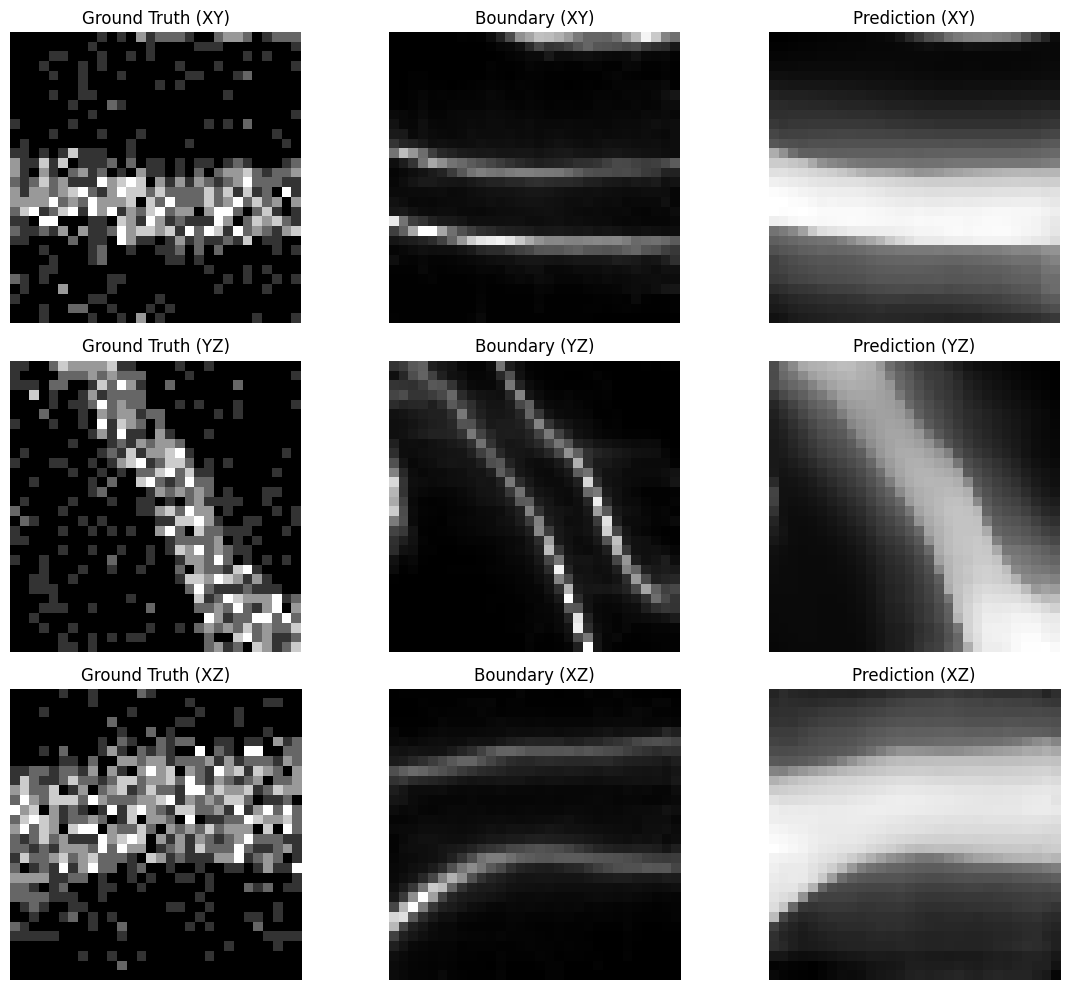

In [3]:
import matplotlib.pyplot as plt
import numpy as np

peak_photon_count =5
gray = patch_np.mean(axis=-1)  # shape: (D, H, W)
scaled = gray * peak_photon_count
noisy = np.random.poisson(scaled).astype(np.float32)
gray_poisson = np.clip(noisy / peak_photon_count, 0.0, 1.0)
patch_np_poisson = np.repeat(gray_poisson[..., np.newaxis], 3, axis=-1)

# Normalize helper
def normalize_gray(x):
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# Convert [D, H, W, C] → [D, H, W] grayscale
gt_img = normalize_gray(patch_np.mean(axis=-1))           # Ground truth
pred_img = normalize_gray(smoothed_img.mean(axis=-1))     # Smoothed prediction
boundary_map = normalize_gray(global_boundaries)          # Detected boundaries

# Mid slice index
mid = gt_img.shape[0] // 2  # Assumes D = H = W

# Create figure
fig, axs = plt.subplots(3, 3, figsize=(12, 10))

# --- XY (Axial) ---
axs[0, 0].imshow(patch_np_poisson[mid], cmap='gray')
axs[0, 0].set_title('Ground Truth (XY)')
axs[0, 0].axis('off')

axs[0, 1].imshow(boundary_map[mid], cmap='gray')
axs[0, 1].set_title('Boundary (XY)')
axs[0, 1].axis('off')

axs[0, 2].imshow(pred_img[mid], cmap='gray')
axs[0, 2].set_title('Prediction (XY)')
axs[0, 2].axis('off')

# --- YZ (Sagittal) ---
axs[1, 0].imshow(patch_np_poisson[:, :, mid], cmap='gray')
axs[1, 0].set_title('Ground Truth (YZ)')
axs[1, 0].axis('off')

axs[1, 1].imshow(boundary_map[:, :, mid], cmap='gray')
axs[1, 1].set_title('Boundary (YZ)')
axs[1, 1].axis('off')

axs[1, 2].imshow(pred_img[:, :, mid], cmap='gray')
axs[1, 2].set_title('Prediction (YZ)')
axs[1, 2].axis('off')

# --- XZ (Coronal) ---
axs[2, 0].imshow(patch_np_poisson[:, mid, :], cmap='gray')
axs[2, 0].set_title('Ground Truth (XZ)')
axs[2, 0].axis('off')

axs[2, 1].imshow(boundary_map[:, mid, :], cmap='gray')
axs[2, 1].set_title('Boundary (XZ)')
axs[2, 1].axis('off')

axs[2, 2].imshow(pred_img[:, mid, :], cmap='gray')
axs[2, 2].set_title('Prediction (XZ)')
axs[2, 2].axis('off')

plt.tight_layout()
plt.show()
